# 👁️ Eye Disease Classification — 3-Model Ensemble
### EfficientNetV2-L + CBAM  ·  ConvNeXt-Large  ·  ViT-Large
**Kaggle | PyTorch**

> **Why ensemble?** Each backbone captures different inductive biases:
> EfficientNetV2 = efficient CNN scaling · ConvNeXt = modern CNN · ViT = global attention.
> Averaging their softmax outputs reduces individual model errors.


In [ ]:
# ── 1. Install & Imports ──────────────────────────────────────────────────
# kagglehub is NOT needed on Kaggle — dataset is mounted directly.
!pip install timm -q

import os, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from copy import deepcopy

from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import tensor, long
from torch.utils.data import Dataset, DataLoader
from torchvision.models import (
    efficientnet_v2_l, EfficientNet_V2_L_Weights,
    convnext_large,   ConvNeXt_Large_Weights,
)
from torchvision.transforms import (
    Compose, ToTensor, Normalize, Resize, CenterCrop,
    RandomHorizontalFlip, RandomRotation, RandomAffine,
    ColorJitter, GaussianBlur, RandomApply,
)
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
)
import timm

# ── Output directory (Kaggle persistent storage) ──────────────────────────
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")
print("All imports loaded.")


Device : cuda
GPU    : Tesla T4
VRAM   : 14.6 GB
All imports loaded.


In [ ]:
# ── 2. Dataset Path (Kaggle-mounted) ──────────────────────────────────────
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

# Print the full tree so we can see exactly what Kaggle mounted
print("=== Mounted dataset structure ===")
for root, dirs, files in os.walk(KAGGLE_INPUT):
    depth = root.replace(str(KAGGLE_INPUT), '').count(os.sep)
    if depth > 3:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")

# Auto-find train/val/test anywhere in the tree
def find_split_dirs(root):
    train_dir = val_dir = test_dir = None
    for dirpath, dirnames, _ in os.walk(root):
        dp = Path(dirpath)
        name = dp.name.lower()
        if name == "train" and train_dir is None:
            train_dir = dp
        elif name in ("val", "valid", "validation") and val_dir is None:
            val_dir = dp
        elif name == "test" and test_dir is None:
            test_dir = dp
        if train_dir and val_dir and test_dir:
            break
    return train_dir, val_dir, test_dir

train_dir, val_dir, test_dir = find_split_dirs(KAGGLE_INPUT)

print("\n=== Resolved split paths ===")
for name, d in [("TRAIN", train_dir), ("VAL", val_dir), ("TEST", test_dir)]:
    if d and d.exists():
        classes = sorted([x for x in os.listdir(d) if (d/x).is_dir()])
        print(f"  {name}: {d}  ({len(classes)} classes)")
    else:
        print(f"  ⚠️  {name}: NOT FOUND")

assert train_dir and train_dir.exists(), "train/ not found"
assert val_dir   and val_dir.exists(),   "val/ not found"
assert test_dir  and test_dir.exists(),  "test/ not found"

=== Mounted dataset structure ===
input/
  notebooks/
    shufanshahi/
      reaugument-notebook/

=== Resolved split paths ===
  TRAIN: /kaggle/input/notebooks/shufanshahi/reaugument-notebook/split_dataset/train  (10 classes)
  VAL: /kaggle/input/notebooks/shufanshahi/reaugument-notebook/split_dataset/val  (10 classes)
  TEST: /kaggle/input/notebooks/shufanshahi/reaugument-notebook/split_dataset/test  (10 classes)


In [ ]:
# ── 2b. GPU memory check ─────────────────────────────────────────────────
if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory — free: {free/1024**3:.1f} GB / total: {total/1024**3:.1f} GB")
else:
    print("No GPU detected — training will be very slow on CPU.")

GPU memory — free: 14.5 GB / total: 14.6 GB


In [ ]:
# ── 3. Class Mapping & DataFrames ───────────────────────────────────────
CLASS_MAPPING = {
    "Central Serous Chorioretinopathy": 0,
    "Diabetic Retinopathy":             1,
    "Disc Edema":                       2,
    "Glaucoma":                         3,
    "Healthy":                          4,
    "Macular Scar":                     5,
    "Myopia":                           6,
    "Pterygium":                        7,
    "Retinal Detachment":               8,
    "Retinitis Pigmentosa":             9,
}
CLASS_NAMES = list(CLASS_MAPPING.keys())
NUM_CLASSES = len(CLASS_NAMES)

def build_dataframe(directory):
    rows = []
    for cls_name, label in CLASS_MAPPING.items():
        cls_dir = directory / cls_name
        if not cls_dir.exists():
            continue
        for f in cls_dir.iterdir():
            if f.suffix.lower() in (".jpg", ".jpeg", ".png"):
                rows.append({"image": str(f), "label": label})
    return pd.DataFrame(rows)

train_df = build_dataframe(train_dir)
val_df   = build_dataframe(val_dir)
test_df  = build_dataframe(test_dir)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


Train: 16357 | Val: 533 | Test: 1068


In [ ]:
# ── 4. PyTorch Dataset & DataLoaders ────────────────────────────────────
# Each backbone has its own preferred image size
IMG_SIZES = {
    "efficientnet": 480,
    "convnext":     384,
    "vit":          224,
}

def make_transforms(img_size, training=True):
    norm = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    if training:
        return Compose([
            Resize((img_size + 32, img_size + 32)),
            RandomRotation(15),
            RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            CenterCrop(img_size),
            RandomHorizontalFlip(),
            ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            RandomApply([GaussianBlur(3, sigma=(0.1, 2.0))], p=0.2),
            ToTensor(), norm,
        ])
    return Compose([Resize((img_size, img_size)), ToTensor(), norm])


class EyeDataset(Dataset):
    def __init__(self, df, img_size=480, training=True):
        self.df = df.reset_index(drop=True)
        self.tf = make_transforms(img_size, training)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:   img = Image.open(row["image"]).convert("RGB")
        except: img = Image.new("RGB", (224, 224))
        return {"image": self.tf(img), "label": tensor(row["label"], dtype=long)}


def make_loaders(img_size, batch=8):
    pin = torch.cuda.is_available()
    # Kaggle allows up to 4 CPU workers; 2 is safe and avoids OOM on shared kernels
    nw = 2
    train_loader = DataLoader(EyeDataset(train_df, img_size, True),
                              batch, shuffle=True,  num_workers=nw,
                              pin_memory=pin, drop_last=True)
    val_loader   = DataLoader(EyeDataset(val_df,   img_size, False),
                              batch, shuffle=False, num_workers=nw, pin_memory=pin)
    test_loader  = DataLoader(EyeDataset(test_df,  img_size, False),
                              batch, shuffle=False, num_workers=nw, pin_memory=pin)
    return train_loader, val_loader, test_loader

print("Dataset & DataLoader factory ready.")


Dataset & DataLoader factory ready.


In [ ]:
# ── 5. CBAM Attention Module ─────────────────────────────────────────────
class ChannelAttention(nn.Module):
    def __init__(self, channels, ratio=16):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.max = nn.AdaptiveMaxPool2d(1)
        self.fc  = nn.Sequential(
            nn.Conv2d(channels, channels // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(channels // ratio, channels, 1, bias=False),
        )
        self.sig = nn.Sigmoid()

    def forward(self, x):
        return self.sig(self.fc(self.avg(x)) + self.fc(self.max(x)))


class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False)
        self.sig  = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        return self.sig(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, ratio=16, k=7):
        super().__init__()
        self.ca = ChannelAttention(channels, ratio)
        self.sa = SpatialAttention(k)

    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

print("CBAM loaded.")


CBAM loaded.


In [ ]:
# ── 6. Model Definitions ─────────────────────────────────────────────────

# ── 6a. EfficientNetV2-L + CBAM ──────────────────────────────────────────
class EfficientModel(nn.Module):
    """EfficientNetV2-L backbone with CBAM attention."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone      = efficientnet_v2_l(weights=EfficientNet_V2_L_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        ch = 1280
        self.cbam     = CBAM(ch)
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(ch, 1024),
            nn.BatchNorm1d(1024), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(1024, 512),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.cbam(self.features(x))
        return self.head(self.pool(x).flatten(1))


# ── 6b. ConvNeXt-Large ───────────────────────────────────────────────────
class ConvNeXtModel(nn.Module):
    """
    ConvNeXt-Large: modern pure-CNN with depthwise convolutions and
    LayerNorm. Complements EfficientNet with different feature patterns.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone        = convnext_large(weights=ConvNeXt_Large_Weights.IMAGENET1K_V1)
        self.features   = backbone.features
        self.avgpool    = backbone.avgpool
        ch = 1536                              # ConvNeXt-Large feature dim
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(ch),
            nn.Dropout(0.4), nn.Linear(ch, 768),
            nn.GELU(),
            nn.Dropout(0.3), nn.Linear(768, num_classes),
        )

    def forward(self, x):
        return self.head(self.avgpool(self.features(x)))


# ── 6c. ViT-Large/16 ─────────────────────────────────────────────────────
class ViTModel(nn.Module):
    """
    Vision Transformer Large (ViT-L/16) via timm.
    Captures global long-range dependencies that CNNs miss — crucial
    for retinal diseases spread across the image.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.vit = timm.create_model(
            "vit_large_patch16_224",
            pretrained=True,
            num_classes=0,        # remove default head
        )
        ch = self.vit.embed_dim   # 1024 for ViT-L
        self.head = nn.Sequential(
            nn.LayerNorm(ch),
            nn.Dropout(0.4), nn.Linear(ch, 512),
            nn.GELU(),
            nn.Dropout(0.3), nn.Linear(512, num_classes),
        )

    def forward(self, x):
        features = self.vit(x)   # (B, embed_dim)
        return self.head(features)


# Verify parameter counts
for name, cls in [("EfficientNetV2-L+CBAM", EfficientModel),
                  ("ConvNeXt-Large",        ConvNeXtModel),
                  ("ViT-Large/16",          ViTModel)]:
    m = cls()
    total = sum(p.numel() for p in m.parameters())
    print(f"{name:<28} {total/1e6:6.1f} M params")
    del m
torch.cuda.empty_cache() if torch.cuda.is_available() else None


Downloading: "https://download.pytorch.org/models/efficientnet_v2_l-59c71312.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_l-59c71312.pth


100%|██████████| 455M/455M [00:02<00:00, 179MB/s]


EfficientNetV2-L+CBAM         119.3 M params
Downloading: "https://download.pytorch.org/models/convnext_large-ea097f82.pth" to /root/.cache/torch/hub/checkpoints/convnext_large-ea097f82.pth


100%|██████████| 755M/755M [00:04<00:00, 189MB/s]


ConvNeXt-Large                197.4 M params


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

ViT-Large/16                  303.8 M params


In [ ]:
# ── 7. Hyperparameters ───────────────────────────────────────────────────
EPOCHS       = 15
LR           = 1.2e-4
WEIGHT_DECAY = 3e-5
GRAD_CLIP    = 0.8
PATIENCE     = 7
ACCUM_STEPS  = 2
USE_AMP      = torch.cuda.is_available()

# Per-model batch sizes (larger models need smaller batches)
BATCH_SIZES = {
    "efficientnet": 8,
    "convnext":     8,
    "vit":          16,   # ViT is more memory-efficient at inference
}

print(f"Epochs={EPOCHS} | LR={LR} | Patience={PATIENCE} | AMP={USE_AMP}")


Epochs=15 | LR=0.00012 | Patience=7 | AMP=True


In [ ]:
# ── 8. Generic Training Function ────────────────────────────────────────
def train_one_model(model, train_loader, val_loader, model_name="model"):
    """Train a single backbone. Returns (trained model, history dict)."""
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=max(1, EPOCHS // 3), eta_min=LR * 0.01)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scaler    = GradScaler() if USE_AMP else None

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state, wait = 0.0, None, 0

    for epoch in range(EPOCHS):
        # ── Train phase ────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        optimizer.zero_grad()

        for i, batch in enumerate(tqdm(train_loader,
                                       desc=f"[{model_name}] Epoch {epoch+1}/{EPOCHS} Train",
                                       leave=False)):
            imgs   = batch["image"].to(device, non_blocking=True)
            labels = batch["label"].to(device, non_blocking=True)

            if USE_AMP:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels) / ACCUM_STEPS
                scaler.scale(loss).backward()
            else:
                out  = model(imgs)
                loss = criterion(out, labels) / ACCUM_STEPS
                loss.backward()

            t_loss    += loss.item()
            t_total   += labels.size(0)
            t_correct += (out.argmax(1) == labels).sum().item()

            if (i + 1) % ACCUM_STEPS == 0 or (i + 1) == len(train_loader):
                if USE_AMP:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(optimizer); scaler.update()
                else:
                    nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()
                optimizer.zero_grad()

        scheduler.step()
        train_acc  = 100 * t_correct / t_total
        train_loss = t_loss / len(train_loader)

        # ── Validation phase ───────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader,
                              desc=f"[{model_name}] Epoch {epoch+1}/{EPOCHS} Val",
                              leave=False):
                imgs   = batch["image"].to(device, non_blocking=True)
                labels = batch["label"].to(device, non_blocking=True)
                if USE_AMP:
                    with autocast(): out = model(imgs); loss = criterion(out, labels)
                else:
                    out = model(imgs); loss = criterion(out, labels)
                v_loss    += loss.item()
                v_total   += labels.size(0)
                v_correct += (out.argmax(1) == labels).sum().item()

        val_acc  = 100 * v_correct / v_total
        val_loss = v_loss / len(val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"  [{model_name}] Ep {epoch+1:02d} | "
              f"train {train_acc:.2f}% / loss {train_loss:.4f} | "
              f"val {val_acc:.2f}% / loss {val_loss:.4f}")

        if val_acc > best_val_acc + 0.05:
            best_val_acc = val_acc
            best_state   = deepcopy(model.state_dict())
            wait = 0
            print(f"    ✅ New best val acc: {best_val_acc:.2f}%")
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"    🛑 Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    print(f"[{model_name}] Training done — best val acc: {best_val_acc:.2f}%\n")
    return model, history

print("Training function ready.")


Training function ready.


In [ ]:
all_histories  = {}
trained_models = {}

# ── 9a. EfficientNetV2-L + CBAM ──────────────────────────────────────────
print("=" * 60)
print("Training EfficientNetV2-L + CBAM")
print("=" * 60)
eff_train, eff_val, eff_test = make_loaders(IMG_SIZES["efficientnet"],
                                            BATCH_SIZES["efficientnet"])
eff_model, eff_hist = train_one_model(EfficientModel(), eff_train, eff_val,
                                      "EfficientNetV2+CBAM")
trained_models["efficientnet"] = eff_model.cpu()
all_histories["efficientnet"]  = eff_hist
torch.save(eff_model.state_dict(), OUTPUT_DIR / "efficientnet_cbam.pth")

# ── 9b. ConvNeXt-Large ───────────────────────────────────────────────────
print("=" * 60)
print("Training ConvNeXt-Large")
print("=" * 60)
cnx_train, cnx_val, cnx_test = make_loaders(IMG_SIZES["convnext"],
                                             BATCH_SIZES["convnext"])
cnx_model, cnx_hist = train_one_model(ConvNeXtModel(), cnx_train, cnx_val,
                                      "ConvNeXt-Large")
trained_models["convnext"] = cnx_model.cpu()
all_histories["convnext"]  = cnx_hist
torch.save(cnx_model.state_dict(), OUTPUT_DIR / "convnext_large.pth")

# ── 9c. ViT-Large/16 ─────────────────────────────────────────────────────
print("=" * 60)
print("Training ViT-Large/16")
print("=" * 60)
vit_train, vit_val, vit_test = make_loaders(IMG_SIZES["vit"],
                                             BATCH_SIZES["vit"])
vit_model, vit_hist = train_one_model(ViTModel(), vit_train, vit_val,
                                      "ViT-Large")
trained_models["vit"] = vit_model.cpu()
all_histories["vit"]  = vit_hist
torch.save(vit_model.state_dict(), OUTPUT_DIR / "vit_large.pth")

print("All three models trained and saved.")

Training EfficientNetV2-L + CBAM


  [EfficientNetV2+CBAM] Ep 01 | train 59.63% / loss 0.7026 | val 73.55% / loss 1.0726
    ✅ New best val acc: 73.55%


  [EfficientNetV2+CBAM] Ep 02 | train 75.53% / loss 0.5298 | val 79.36% / loss 0.9748
    ✅ New best val acc: 79.36%


  [EfficientNetV2+CBAM] Ep 03 | train 81.05% / loss 0.4703 | val 79.74% / loss 0.9925
    ✅ New best val acc: 79.74%


  [EfficientNetV2+CBAM] Ep 04 | train 84.88% / loss 0.4285 | val 79.92% / loss 0.9912
    ✅ New best val acc: 79.92%


...

  [ViT-Large] Ep 07 | train 82.23% / loss 0.4391 | val 74.48% / loss 1.0162


  [ViT-Large] Ep 08 | train 84.78% / loss 0.4080 | val 77.49% / loss 1.0053


  [ViT-Large] Ep 09 | train 87.72% / loss 0.3748 | val 76.74% / loss 1.0257


  [ViT-Large] Ep 10 | train 90.29% / loss 0.3458 | val 75.61% / loss 1.0790


  [ViT-Large] Ep 11 | train 84.64% / loss 0.4121 | val 75.23% / loss 1.0648
    🛑 Early stopping at epoch 11
[ViT-Large] Training done — best val acc: 79.74%

All three models trained and saved.


In [ ]:
# ── 10. Evaluate Each Model Individually ────────────────────────────────
def evaluate(model, loader, model_name="model"):
    model = model.to(device)
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Evaluating {model_name}", leave=False):
            imgs   = batch["image"].to(device)
            labels = batch["label"]
            if USE_AMP:
                with autocast(): out = model(imgs)
            else:
                out = model(imgs)
            preds.extend(out.argmax(1).cpu().numpy())
            targets.extend(labels.numpy())
    model.cpu()
    preds, targets = np.array(preds), np.array(targets)
    acc = accuracy_score(targets, preds)
    _, _, f1, _ = precision_recall_fscore_support(targets, preds,
                                                   average="macro", zero_division=0)
    cm = confusion_matrix(targets, preds)
    return dict(accuracy=acc, f1=f1, cm=cm, preds=preds, targets=targets)


# Evaluate each model on its own test loader
ind_results = {}
ind_results["efficientnet"] = evaluate(trained_models["efficientnet"],
                                        eff_test, "EfficientNetV2+CBAM")
ind_results["convnext"]     = evaluate(trained_models["convnext"],
                                        cnx_test, "ConvNeXt-Large")
ind_results["vit"]          = evaluate(trained_models["vit"],
                                        vit_test, "ViT-Large")

print("\n── Individual Model Results ───────────────────────────────────────")
for name, res in ind_results.items():
    print(f"  {name:<20}  Acc={res['accuracy']*100:.2f}%  F1={res['f1']:.4f}")



── Individual Model Results ───────────────────────────────────────
  efficientnet          Acc=77.53%  F1=0.7979
  convnext              Acc=77.62%  F1=0.8018
  vit                   Acc=78.46%  F1=0.7988


In [ ]:
# ── 11. Weighted Soft-Voting Ensemble ───────────────────────────────────
# Strategy: collect raw softmax probabilities from every model,
# weight them by their individual val accuracy, then average.
# This is more powerful than hard (majority) voting.

def collect_probs(model, loader):
    """Return (N, C) softmax probability matrix and (N,) target array."""
    model = model.to(device)
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Collecting probs", leave=False):
            imgs   = batch["image"].to(device)
            labels = batch["label"]
            if USE_AMP:
                with autocast(): logits = model(imgs)
            else:
                logits = model(imgs)
            probs = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu())
            all_targets.append(labels)
    model.cpu()
    return torch.cat(all_probs).numpy(), torch.cat(all_targets).numpy()


# Collect probs — each model uses its own test loader (correct image size)
print("Collecting softmax probabilities from each model...")
eff_probs, targets = collect_probs(trained_models["efficientnet"], eff_test)
cnx_probs, _       = collect_probs(trained_models["convnext"],     cnx_test)
vit_probs, _       = collect_probs(trained_models["vit"],          vit_test)

# Weights = individual val accuracies (auto-normalised below)
w_eff = max(all_histories["efficientnet"]["val_acc"])
w_cnx = max(all_histories["convnext"]["val_acc"])
w_vit = max(all_histories["vit"]["val_acc"])
total_w = w_eff + w_cnx + w_vit
w_eff /= total_w;  w_cnx /= total_w;  w_vit /= total_w
print(f"Ensemble weights — EfficientNet: {w_eff:.3f} | ConvNeXt: {w_cnx:.3f} | ViT: {w_vit:.3f}")

# Weighted average of probabilities
ensemble_probs = w_eff * eff_probs + w_cnx * cnx_probs + w_vit * vit_probs
ensemble_preds = ensemble_probs.argmax(axis=1)

# Metrics
ens_acc = accuracy_score(targets, ensemble_preds)
_, _, ens_f1, _ = precision_recall_fscore_support(targets, ensemble_preds,
                                                   average="macro", zero_division=0)
ens_cm = confusion_matrix(targets, ensemble_preds)

print(f"\n══ ENSEMBLE TEST RESULTS ══")
print(f"  Accuracy : {ens_acc*100:.2f}%")
print(f"  Macro F1 : {ens_f1:.4f}")
print("\n", classification_report(targets, ensemble_preds,
                                    target_names=CLASS_NAMES, zero_division=0))


Ensemble weights — EfficientNet: 0.333 | ConvNeXt: 0.335 | ViT: 0.332

══ ENSEMBLE TEST RESULTS ══
  Accuracy : 79.96%
  Macro F1 : 0.8169

                                   precision    recall  f1-score   support

Central Serous Chorioretinopathy       0.75      0.75      0.75        20
            Diabetic Retinopathy       0.96      0.92      0.94       302
                      Disc Edema       0.73      0.92      0.81        26
                        Glaucoma       0.74      0.73      0.73       270
                         Healthy       0.73      0.83      0.78       205
                    Macular Scar       0.73      0.65      0.69        89
                          Myopia       0.68      0.58      0.63       100
                       Pterygium       1.00      1.00      1.00         3
              Retinal Detachment       0.96      0.96      0.96        25
            Retinitis Pigmentosa       0.86      0.89      0.88        28

                        accuracy           

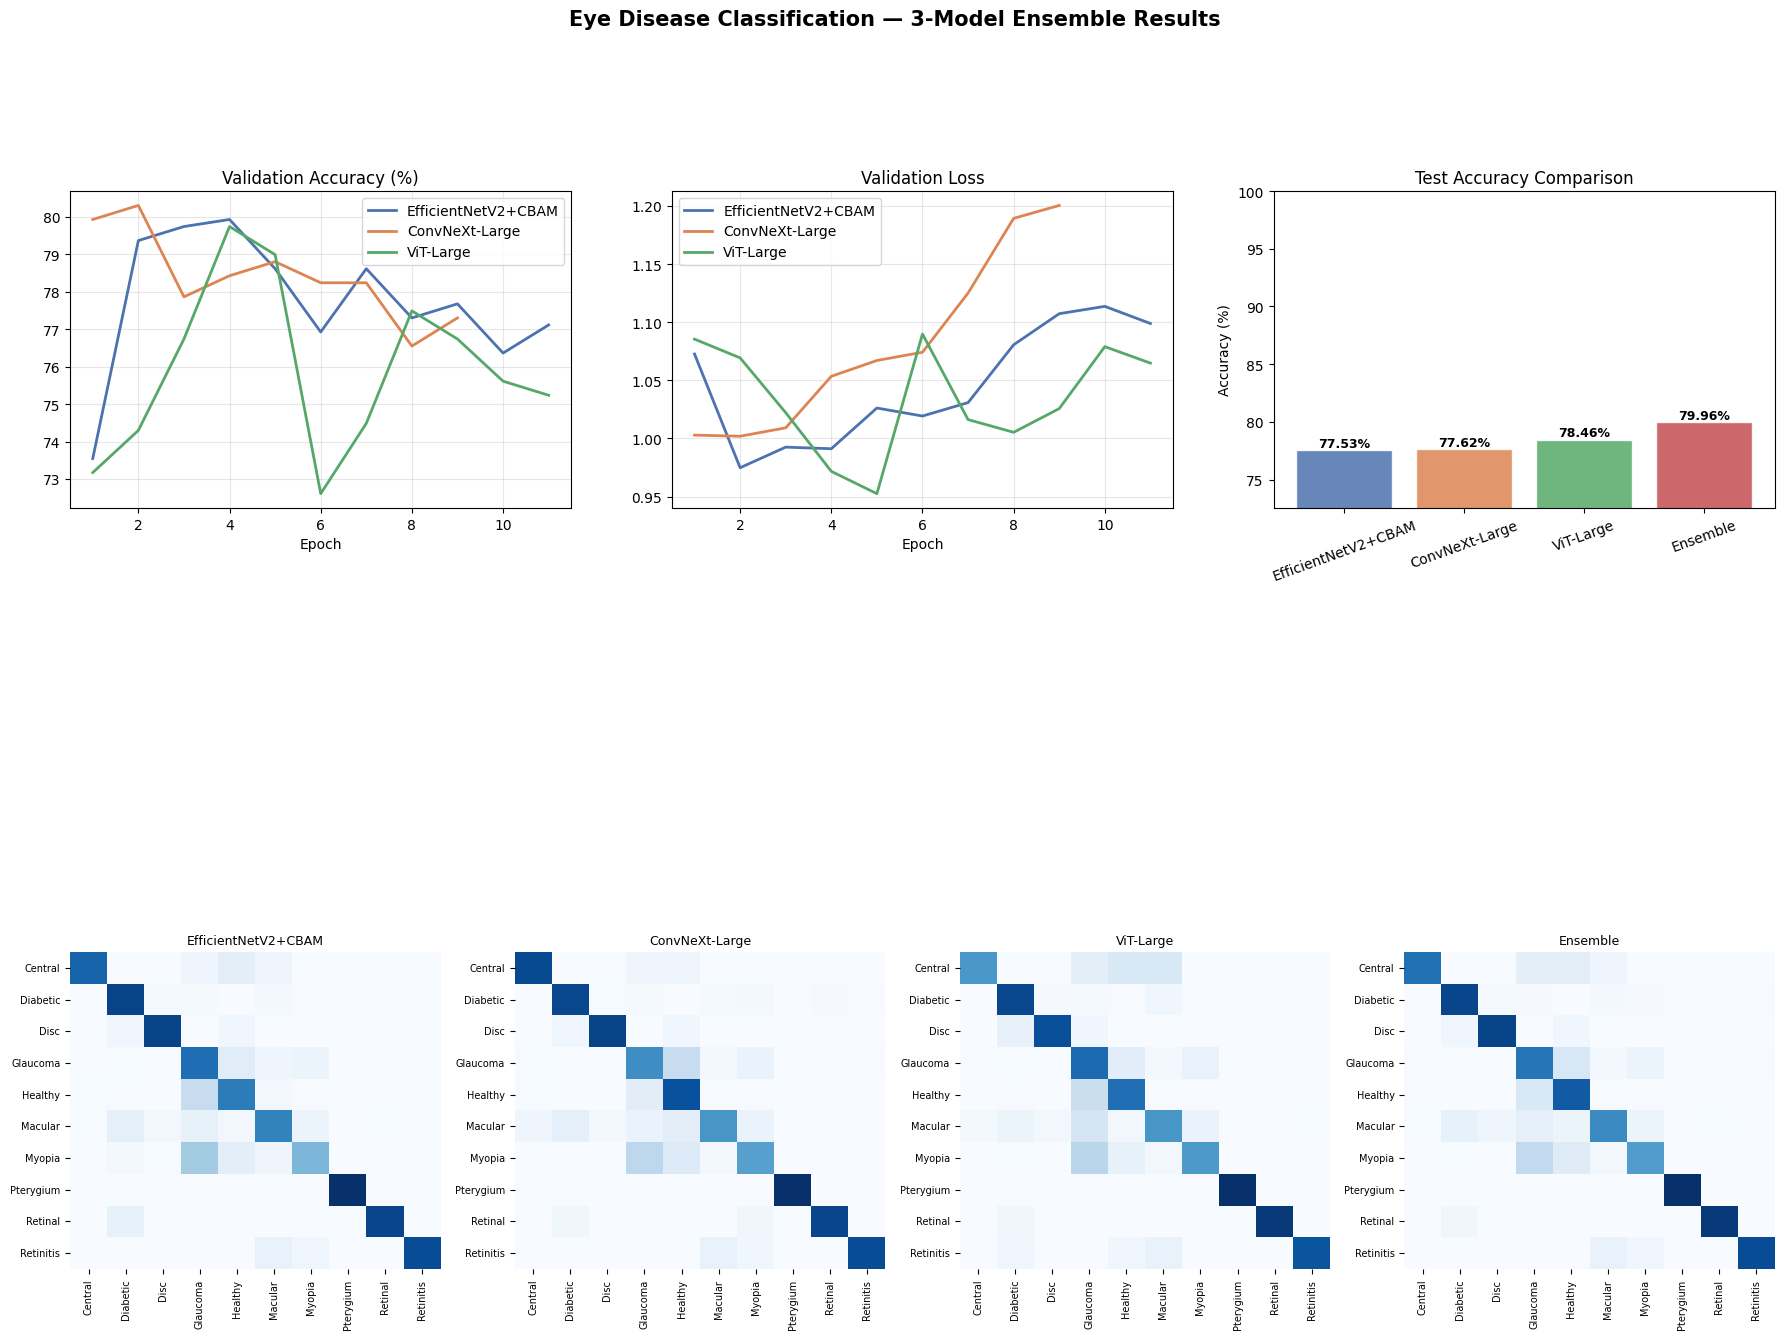

In [ ]:
# ── 12. Visualisations ───────────────────────────────────────────────────
MODEL_LABELS = {"efficientnet": "EfficientNetV2+CBAM",
                "convnext":     "ConvNeXt-Large",
                "vit":          "ViT-Large"}
COLORS = {"efficientnet": "#4C72B0", "convnext": "#DD8452", "vit": "#55A868"}

fig = plt.figure(figsize=(22, 14))

# ── Row 1: Training curves ────────────────────────────────────────────────
for col, metric in enumerate(["val_acc", "val_loss"]):
    ax = fig.add_subplot(3, 3, col + 1)
    for key, hist in all_histories.items():
        ep = range(1, len(hist[metric]) + 1)
        ax.plot(ep, hist[metric], label=MODEL_LABELS[key],
                color=COLORS[key], linewidth=2)
    ax.set_title("Validation " + ("Accuracy (%)" if "acc" in metric else "Loss"))
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)

# ── Accuracy bar chart: individuals vs ensemble ───────────────────────────
ax = fig.add_subplot(3, 3, 3)
names = [MODEL_LABELS[k] for k in MODEL_LABELS] + ["Ensemble"]
accs  = [ind_results[k]["accuracy"] * 100 for k in MODEL_LABELS] + [ens_acc * 100]
bar_colors = list(COLORS.values()) + ["#C44E52"]
bars = ax.bar(names, accs, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{acc:.2f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_ylim(min(accs) - 5, 100)
ax.set_title("Test Accuracy Comparison"); ax.set_ylabel("Accuracy (%)")
ax.tick_params(axis="x", rotation=20)

# ── Confusion matrices (one per model + ensemble) ─────────────────────────
SHORT = [c.split()[0] for c in CLASS_NAMES]
plot_items = list(MODEL_LABELS.items()) + [("ensemble", "Ensemble")]
cms = {k: ind_results[k]["cm"] for k in MODEL_LABELS}
cms["ensemble"] = ens_cm

for idx, (key, label) in enumerate(plot_items):
    ax = fig.add_subplot(3, 4, 9 + idx)
    cm_n = cms[key].astype(float) / (cms[key].sum(axis=1, keepdims=True) + 1e-9)
    sns.heatmap(cm_n, annot=False, cmap="Blues", ax=ax, vmin=0, vmax=1,
                xticklabels=SHORT, yticklabels=SHORT, cbar=False)
    ax.set_title(label, fontsize=9)
    ax.tick_params(labelsize=7)

plt.suptitle("Eye Disease Classification — 3-Model Ensemble Results",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── 13. Save All Models ───────────────────────────────────────────────────
torch.save(trained_models["efficientnet"].state_dict(), OUTPUT_DIR / "efficientnet_cbam.pth")
torch.save(trained_models["convnext"].state_dict(),     OUTPUT_DIR / "convnext_large.pth")
torch.save(trained_models["vit"].state_dict(),          OUTPUT_DIR / "vit_large.pth")

# Save ensemble weights for reproducible inference
ensemble_config = {"w_efficientnet": float(w_eff),
                   "w_convnext":     float(w_cnx),
                   "w_vit":          float(w_vit),
                   "img_sizes":      IMG_SIZES}
with open(OUTPUT_DIR / "ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=2)

print("Saved:")
print("  /kaggle/working/efficientnet_cbam.pth")
print("  /kaggle/working/convnext_large.pth")
print("  /kaggle/working/vit_large.pth")
print("  /kaggle/working/ensemble_config.json  ← weights for future inference")

print(f"\n══ FINAL SUMMARY ══════════════════════════════════════════")
for k, label in MODEL_LABELS.items():
    print(f"  {label:<28} Acc={ind_results[k]['accuracy']*100:.2f}%  F1={ind_results[k]['f1']:.4f}")
print(f"  {'Ensemble (weighted avg)':<28} Acc={ens_acc*100:.2f}%  F1={ens_f1:.4f}")


Saved:
  /kaggle/working/efficientnet_cbam.pth
  /kaggle/working/convnext_large.pth
  /kaggle/working/vit_large.pth
  /kaggle/working/ensemble_config.json  ← weights for future inference

══ FINAL SUMMARY ══════════════════════════════════════════
  EfficientNetV2+CBAM          Acc=77.53%  F1=0.7979
  ConvNeXt-Large               Acc=77.62%  F1=0.8018
  ViT-Large                    Acc=78.46%  F1=0.7988
  Ensemble (weighted avg)      Acc=79.96%  F1=0.8169
